In [1]:
import pandas as pd

data = pd.read_csv("U4_04_train.csv")

In [2]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


<Axes: xlabel='Survived', ylabel='count'>

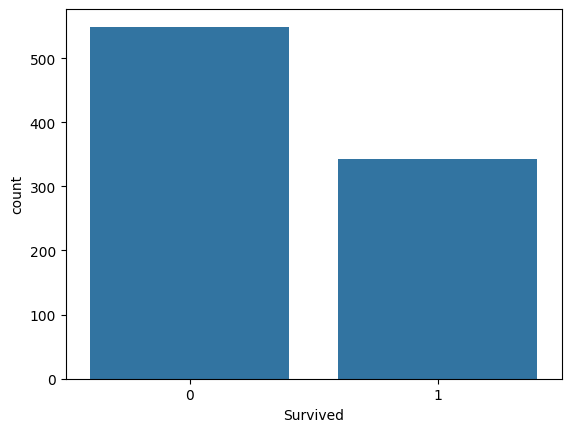

In [5]:
import seaborn as sb
sb.countplot(x="Survived", data=data)

<Axes: xlabel='Survived', ylabel='count'>

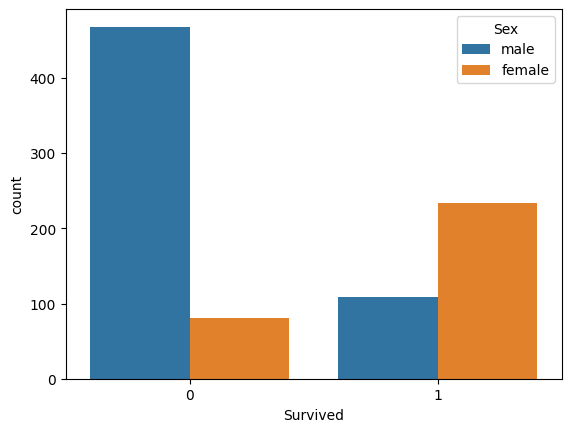

In [6]:
sb.countplot(x="Survived", data=data, hue="Sex")

In [7]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

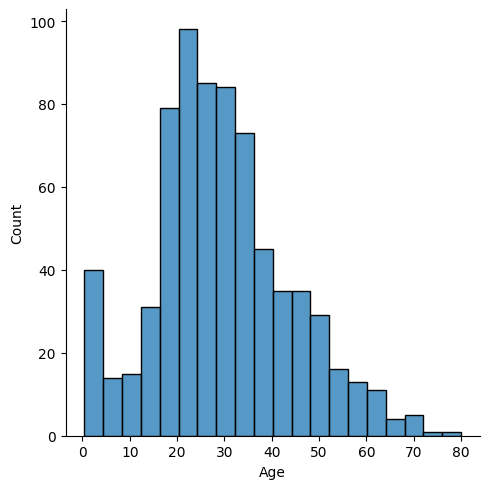

In [8]:
sb.displot(x="Age", data=data)

In [9]:
data["Age"].mean()

np.float64(29.69911764705882)

In [10]:
data["Age"].fillna(data["Age"].mean(), inplace=True)

C:\Users\peter\AppData\Local\Temp\ipykernel_15732\493785903.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["Age"].fillna(data["Age"].mean(), inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [11]:
data["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [12]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
data.drop("Cabin", axis=1, inplace=True)

In [14]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [15]:
data.dropna(inplace=True)

In [16]:
data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [17]:
data.drop(["Name", "PassengerId", "Ticket"], axis=1, inplace=True)

In [18]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [19]:
dummies = pd.get_dummies(data["Sex"], drop_first = True, dtype=int)

In [20]:
data = data.join(dummies)

In [21]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,male
0,0,3,male,22.0,1,0,7.2500,S,1
1,1,1,female,38.0,1,0,71.2833,C,0
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,0
4,0,3,male,35.0,0,0,8.0500,S,1


In [22]:
data = data.drop("Sex", axis=1)

<Axes: xlabel='Survived', ylabel='count'>

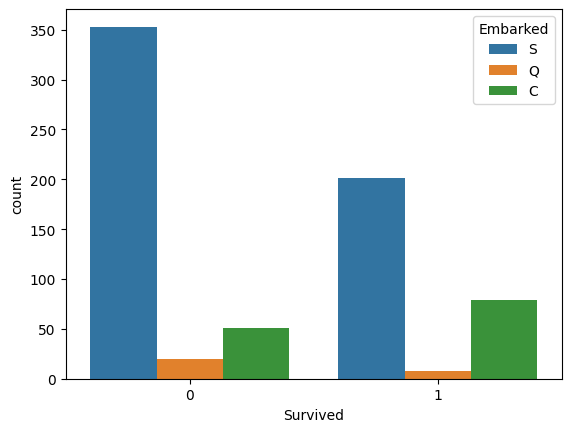

In [23]:
sb.countplot(x="Survived", data=data, hue="Embarked")

In [24]:
dummies_embarked = pd.get_dummies(data["Embarked"], dtype=int, drop_first=True)

In [25]:
data = data.join(dummies_embarked)
data = data.drop("Embarked", axis=1)

<Axes: >

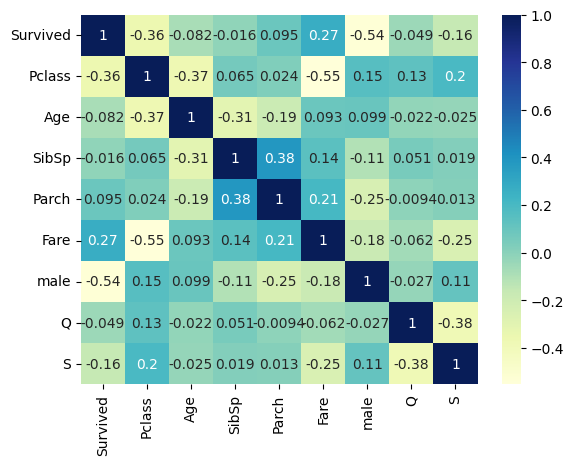

In [26]:
sb.heatmap(data.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='Survived', ylabel='count'>

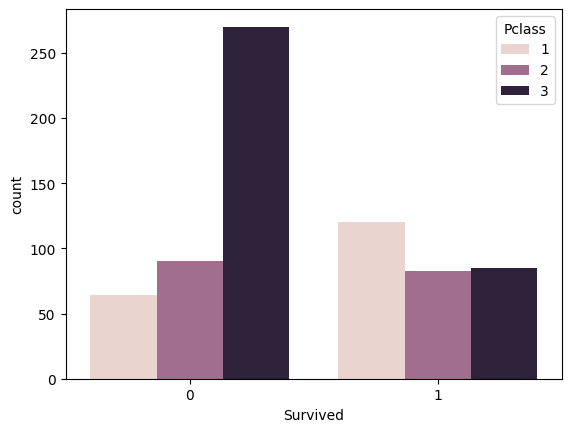

In [27]:
sb.countplot(x="Survived", data=data, hue="Pclass")

In [28]:
X = data.drop("Survived", axis = 1)
y = data["Survived"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2)

In [48]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=10)
model.fit(X_train, y_train)
prediksi = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, prediksi)

0.7552447552447552

In [50]:
from sklearn.tree import DecisionTreeClassifier

hasil = []
for i in range(1,15):
  model = DecisionTreeClassifier(max_depth=i)
  model.fit(X_train, y_train)
  prediksi = model.predict(X_test)
  ketepatan = accuracy_score(y_test, prediksi)
  print(f"Hasil untuk {i}: {ketepatan}")
  hasil.append(ketepatan)

Hasil untuk 1: 0.8181818181818182
Hasil untuk 2: 0.7902097902097902
Hasil untuk 3: 0.8251748251748252
Hasil untuk 4: 0.7972027972027972
Hasil untuk 5: 0.7972027972027972
Hasil untuk 6: 0.7762237762237763
Hasil untuk 7: 0.7552447552447552
Hasil untuk 8: 0.7552447552447552
Hasil untuk 9: 0.7762237762237763
Hasil untuk 10: 0.7412587412587412
Hasil untuk 11: 0.7692307692307693
Hasil untuk 12: 0.7342657342657343
Hasil untuk 13: 0.7342657342657343
Hasil untuk 14: 0.7412587412587412


<Axes: >

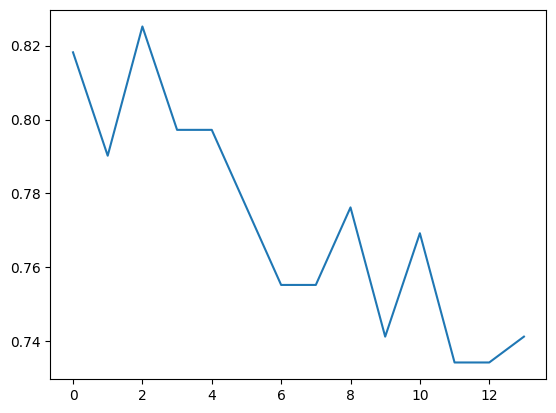

In [56]:
sb.lineplot(data=hasil)

In [52]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
prediksi = model.predict(X_test)
ketepatan = accuracy_score(y_test, prediksi)

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediksi))

              precision    recall  f1-score   support

           0       0.80      0.94      0.86        84
           1       0.89      0.66      0.76        59

    accuracy                           0.83       143
   macro avg       0.84      0.80      0.81       143
weighted avg       0.83      0.83      0.82       143



In [55]:
from sklearn.metrics import confusion_matrix

pd.DataFrame(confusion_matrix(y_test, prediksi), columns=["Prediksi: 1", "Prediksi: 2"], index=["Aktual: 1", "Aktual: 2"])

,Prediksi: 1,Prediksi: 2
Aktual: 1,79,5
Aktual: 2,20,39


In [ ]:
X_train.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q', 'S'], dtype='object')

[Text(0.38423295454545453, 0.9444444444444444, 'male <= 0.5\ngini = 0.471\nsamples = 711\nvalue = [441, 270]\nclass = Mati'),
 Text(0.19211647727272727, 0.8333333333333334, 'Pclass <= 2.5\ngini = 0.381\nsamples = 242\nvalue = [62.0, 180.0]\nclass = Hidup'),
 Text(0.2881747159090909, 0.8888888888888888, 'True  '),
 Text(0.07386363636363637, 0.7222222222222222, 'Age <= 2.5\ngini = 0.097\nsamples = 137\nvalue = [7, 130]\nclass = Hidup'),
 Text(0.05113636363636364, 0.6111111111111112, 'Parch <= 1.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = Mati'),
 Text(0.03977272727272727, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Hidup'),
 Text(0.0625, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = Mati'),
 Text(0.09659090909090909, 0.6111111111111112, 'Fare <= 28.856\ngini = 0.085\nsamples = 135\nvalue = [6, 129]\nclass = Hidup'),
 Text(0.08522727272727272, 0.5, 'Fare <= 28.231\ngini = 0.188\nsamples = 57\nvalue = [6, 51]\nclass = Hidup'),
 Text(0.07386363636363637, 0.388888

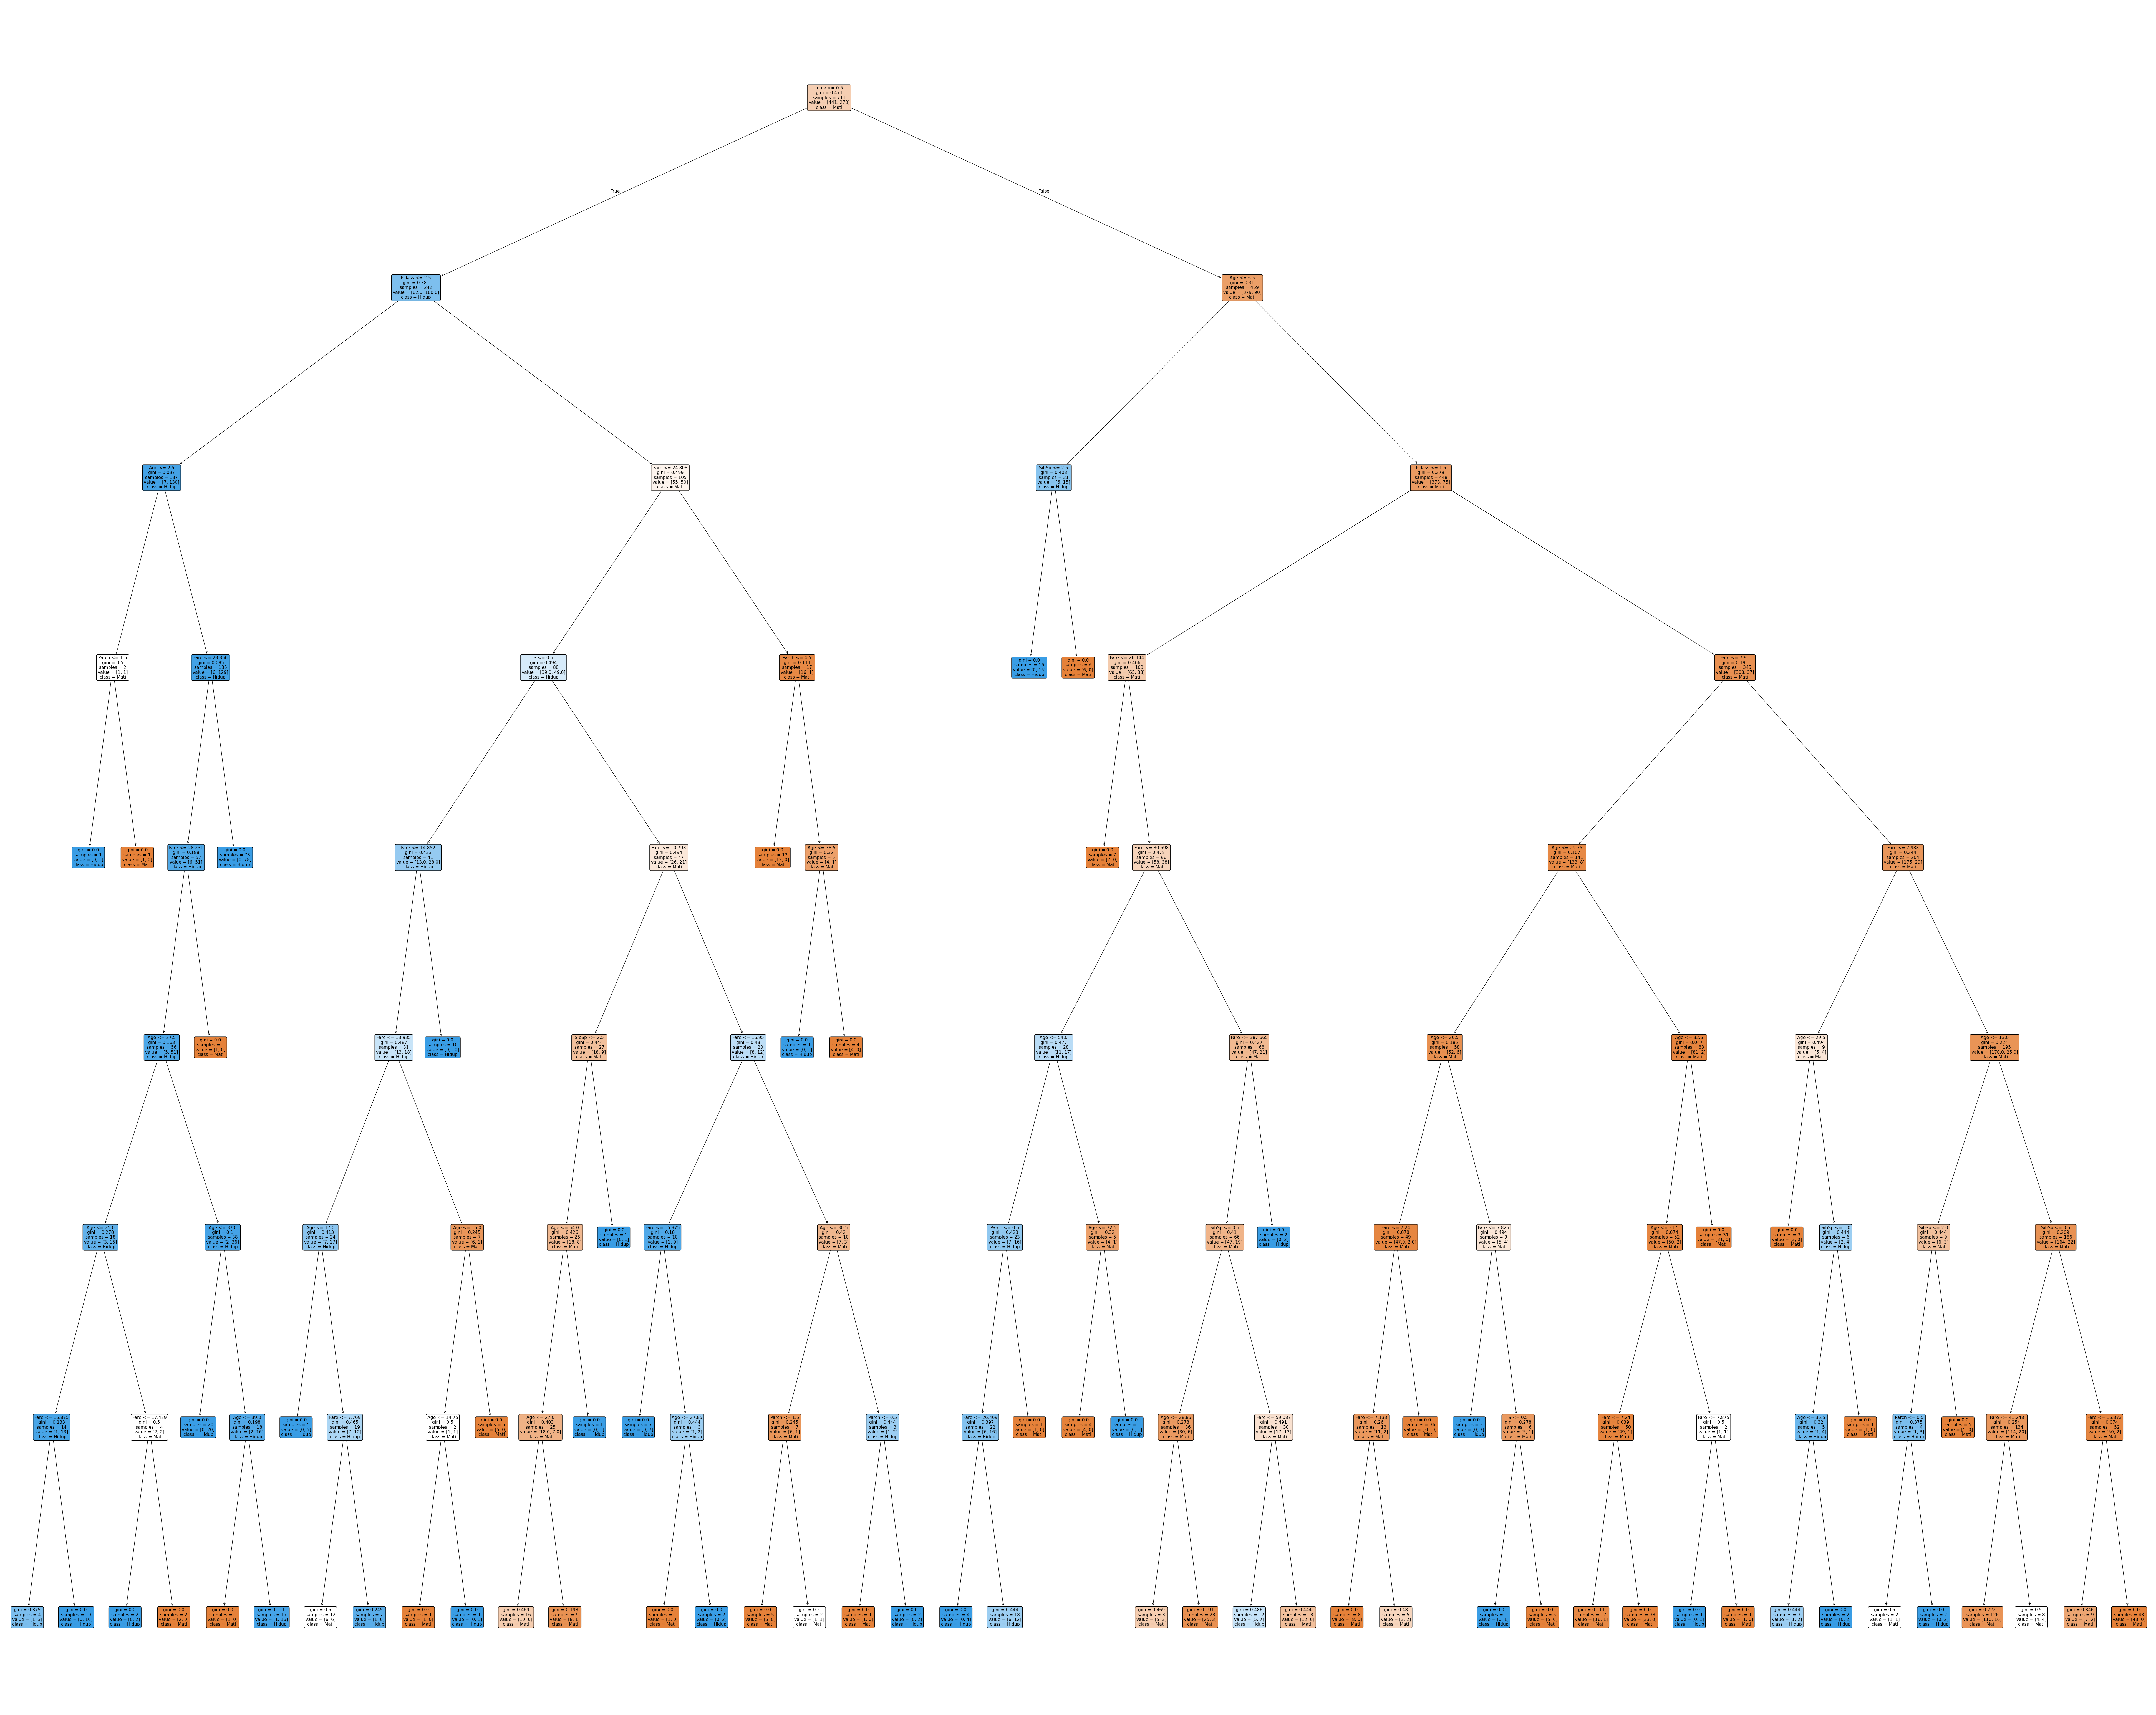

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100,80))
plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=["Mati", "Hidup"],
    filled=True,
    rounded=True
)